<a href="https://colab.research.google.com/github/RahulTechTutorials/Python-Application/blob/master/Roller_coaster_dataset_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 0 : Data Loading
- Libraries Import
- Dataset load

In [11]:
##!pip install ydata_profiling

In [208]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import os
import re

plt.style.use('ggplot')
%matplotlib inline

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 20)

"""import kagglehub

# Download latest version
path = kagglehub.dataset_download("robikscube/rollercoaster-database")

print("Path to dataset files:", path)
"""

'import kagglehub\n\n# Download latest version\npath = kagglehub.dataset_download("robikscube/rollercoaster-database")\n\nprint("Path to dataset files:", path)\n'

In [13]:
from google.colab import userdata
os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")

In [14]:
os.listdir()

['.config', 'coaster_db.csv', 'sample_data']

In [15]:
df = pd.read_csv('coaster_db.csv')

# Step 1 : Data Understanding
- Shape
- head, tail
- dtype
- describe


In [16]:
df.head()

,coaster_name,Length,Speed,Location,Status,Opening date,Type,Manufacturer,Height restriction,Model,Height,Inversions,Lift/launch system,Cost,Trains,Park section,Duration,Capacity,G-force,Designer,Max vertical angle,Drop,Soft opening date,Fast Lane available,Replaced,Track layout,Fastrack available,Soft opening date.1,Closing date,Opened,Replaced by,Website,Flash Pass Available,Must transfer from wheelchair,Theme,Single rider line available,Restraint Style,Flash Pass available,Acceleration,Restraints,Name,year_introduced,latitude,longitude,Type_Main,opening_date_clean,speed1,speed2,speed1_value,speed1_unit,speed_mph,height_value,height_unit,height_ft,Inversions_clean,Gforce_clean
0,Switchback Railway,600 ft (180 m),6 mph (9.7 km/h),Coney Island,Removed,"June 16, 1884",Wood,LaMarcus Adna Thompson,NaN,Lift Packed,50 ft (15 m),NaN,gravity,NaN,NaN,Coney Island Cyclone Site,1:00,1600 riders per hour,2.9,LaMarcus Adna Thompson,30°,43 ft (13 m),NaN,NaN,NaN,Gravity pulled coaster,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1884,40.5740,-73.9780,Wood,1884-06-16,6 mph,9.7 km/h,6.0,mph,6.0,50.0,ft,NaN,0,2.9
1,Flip Flap Railway,NaN,NaN,Sea Lion Park,Removed,1895,Wood,Lina Beecher,NaN,NaN,NaN,1.0,NaN,NaN,a single car. Riders are arranged 1 across in ...,NaN,NaN,NaN,12,Lina Beecher,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1902,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),NaN,NaN,"Cleveland, Ohio, United States",Closed,NaN,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1896,41.5800,-81.5700,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,NaN,1.0,NaN,NaN,a single car. Riders are arranged 2 across in ...,NaN,NaN,NaN,NaN,Edward A. Green,NaN,NaN,NaN,NaN,Switchback Railway,NaN,NaN,NaN,1910,NaN,Giant Racer,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),NaN,NaN,Other,Removed,1901,Steel,Edwin Prescott,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Edward A. Green,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1912,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN


In [17]:
df.shape

(1087, 56)

In [19]:
df.columns

Index(['coaster_name', 'Length', 'Speed', 'Location', 'Status', 'Opening date',
       'Type', 'Manufacturer', 'Height restriction', 'Model', 'Height',
       'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
       'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
       'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
       'Track layout', 'Fastrack available', 'Soft opening date.1',
       'Closing date', 'Opened', 'Replaced by', 'Website',
       'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
       'Single rider line available', 'Restraint Style',
       'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean', 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph', 'height_value', 'height_unit', 'height_ft',
       'Inversions_clean', 'Gforce_clean'],
      dtype='object')

In [20]:
df.dtypes

,0
coaster_name,object
Length,object
Speed,object
Location,object
Status,object
Opening date,object
Type,object
Manufacturer,object
Height restriction,object
Model,object


In [21]:
df.describe()

,Inversions,year_introduced,latitude,longitude,speed1_value,speed_mph,height_value,height_ft,Inversions_clean,Gforce_clean
count,932.000000,1087.000000,812.000000,812.000000,937.000000,937.000000,965.000000,171.000000,1087.000000,362.000000
mean,1.547210,1994.986201,38.373484,-41.595373,53.850374,48.617289,89.575171,101.996491,1.326587,3.824006
std,2.114073,23.475248,15.516596,72.285227,23.385518,16.678031,136.246444,67.329092,2.030854,0.989998
min,0.000000,1884.000000,-48.261700,-123.035700,5.000000,5.000000,4.000000,13.100000,0.000000,0.800000
25%,0.000000,1989.000000,35.031050,-84.552200,40.000000,37.300000,44.000000,51.800000,0.000000,3.400000
50%,0.000000,2000.000000,40.289800,-76.653600,50.000000,49.700000,79.000000,91.200000,0.000000,4.000000
75%,3.000000,2010.000000,44.799600,2.778100,63.000000,58.000000,113.000000,131.200000,2.000000,4.500000
max,14.000000,2022.000000,63.230900,153.426500,240.000000,149.100000,3937.000000,377.300000,14.000000,12.000000


# Step 2 : Data Preparation
- pping irrelevant column and Rows
- Identifying duplicate rows
- naming columns
- Feature Creation

In [23]:
object_cols = [col for col,type in df.dtypes.items() if type=='object']
int_cols    = [col for col,type in df.dtypes.items() if type=='int64' or type=='float64']

In [24]:
int_cols

['Inversions',
 'year_introduced',
 'latitude',
 'longitude',
 'speed1_value',
 'speed_mph',
 'height_value',
 'height_ft',
 'Inversions_clean',
 'Gforce_clean']

In [25]:
df = df[['coaster_name',
    ##'Length', 'Speed',
    'Location', 'Status',
    ##'Opening date','Type',
    'Manufacturer',
    ##'Height restriction', 'Model', 'Height',
      #  'Inversions', 'Lift/launch system', 'Cost', 'Trains', 'Park section',
      #  'Duration', 'Capacity', 'G-force', 'Designer', 'Max vertical angle',
      #  'Drop', 'Soft opening date', 'Fast Lane available', 'Replaced',
      #  'Track layout', 'Fastrack available', 'Soft opening date.1',
      #  'Closing date', 'Opened', 'Replaced by', 'Website',
      #  'Flash Pass Available', 'Must transfer from wheelchair', 'Theme',
      #  'Single rider line available', 'Restraint Style',
      #  'Flash Pass available', 'Acceleration', 'Restraints', 'Name',
       'year_introduced', 'latitude', 'longitude', 'Type_Main',
       'opening_date_clean',
    # 'speed1', 'speed2', 'speed1_value', 'speed1_unit',
       'speed_mph',
    # 'height_value', 'height_unit',
    'height_ft',
       'Inversions_clean', 'Gforce_clean'] ].copy()

In [26]:
df.shape

(1087, 13)

In [27]:
df.dtypes

,0
coaster_name,object
Location,object
Status,object
Manufacturer,object
year_introduced,int64
latitude,float64
longitude,float64
Type_Main,object
opening_date_clean,object
speed_mph,float64


In [28]:
df['opening_date_clean'] = pd.to_datetime(df['opening_date_clean'])

In [29]:
df.dtypes

,0
coaster_name,object
Location,object
Status,object
Manufacturer,object
year_introduced,int64
latitude,float64
longitude,float64
Type_Main,object
opening_date_clean,datetime64[ns]
speed_mph,float64


##Renaming the columns

In [30]:
col_list = list(df.columns.values)

In [31]:
col_rename_dict = {col: col.lower().replace('_','') for col in col_list }

In [32]:
df.columns

Index(['coaster_name', 'Location', 'Status', 'Manufacturer', 'year_introduced',
       'latitude', 'longitude', 'Type_Main', 'opening_date_clean', 'speed_mph',
       'height_ft', 'Inversions_clean', 'Gforce_clean'],
      dtype='object')

In [33]:
df = df.rename(columns = col_rename_dict)

In [34]:
df.columns

Index(['coastername', 'location', 'status', 'manufacturer', 'yearintroduced',
       'latitude', 'longitude', 'typemain', 'openingdateclean', 'speedmph',
       'heightft', 'inversionsclean', 'gforceclean'],
      dtype='object')

In [35]:
df.head()

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdateclean,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


In [36]:
##df.isnull().sum()
df.isna().sum()

,0
coastername,0
location,0
status,213
manufacturer,59
yearintroduced,0
latitude,275
longitude,275
typemain,0
openingdateclean,250
speedmph,150


In [37]:
df.loc[df.duplicated()]

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdateclean,speedmph,heightft,inversionsclean,gforceclean


In [38]:
df.loc[df.duplicated(subset=['coastername'])]

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdateclean,speedmph,heightft,inversionsclean,gforceclean
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
60,Derby Racer,Revere Beach,Removed,Fred W. Pearce,1937,42.4200,-70.9860,Wood,1911-01-01,NaN,NaN,0,NaN
61,Blue Streak (Conneaut Lake),Conneaut Lake Park,Closed,NaN,1938,41.6349,-80.3180,Wood,1938-05-23,50.0,NaN,0,NaN
167,Big Thunder Mountain Railroad,Other,NaN,Arrow Development (California and Florida)Dyna...,1980,NaN,NaN,Steel,NaT,35.0,NaN,0,NaN
237,Thunder Run (Canada's Wonderland),Canada's Wonderland,Operating,Mack Rides,1986,43.8427,-79.5423,Steel,1981-05-23,39.8,32.8,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,Lil' Devil Coaster,Six Flags Great Adventure,Operating,Zamperla,2021,40.1343,-74.4434,Steel,1999-01-01,NaN,NaN,0,NaN
1064,Little Dipper (Conneaut Lake Park),Conneaut Lake Park,Operating,Allan Herschell Company,2021,41.6343,-80.3165,Steel,1950-01-01,NaN,NaN,0,NaN
1080,Iron Gwazi,Busch Gardens Tampa Bay,Under construction,Rocky Mountain Construction,2022,28.0339,-82.4231,Steel,NaT,76.0,NaN,2,NaN
1082,American Dreier Looping,Other,NaN,Anton Schwarzkopf,2022,NaN,NaN,Steel,NaT,53.0,NaN,3,4.7


In [39]:
df[df.coastername =='Derby Racer']

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdateclean,speedmph,heightft,inversionsclean,gforceclean
14,Derby Racer,Revere Beach,Removed,Fred W. Pearce,1911,42.42,-70.986,Wood,1911-01-01,NaN,NaN,0,NaN
60,Derby Racer,Revere Beach,Removed,Fred W. Pearce,1937,42.42,-70.986,Wood,1911-01-01,NaN,NaN,0,NaN


In [40]:
df.query("coastername == 'Crystal Beach Cyclone'")

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdateclean,speedmph,heightft,inversionsclean,gforceclean
39,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1926,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0
43,Crystal Beach Cyclone,Crystal Beach Park,Removed,Traver Engineering,1927,42.8617,-79.0598,Wood,1926-01-01,60.0,NaN,0,4.0


In [41]:
df.shape

(1087, 13)

In [42]:
df_dedup = df.drop(df[df.duplicated(subset=['coastername'])].index,axis=0)

In [43]:
df_dedup.shape

(990, 13)

In [44]:
df.head()
df.rename(columns = {'openingdateclean' : 'openingdate'},inplace=True)

In [45]:
df_dedup2 = df.loc[~df.duplicated(subset=['coastername','location','openingdate'])]\
.reset_index(drop=True).copy()

In [46]:
df_dedup2.head()

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


In [47]:
df_dedup2

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,Ice Breaker (roller coaster),SeaWorld Orlando,Under construction,Premier Rides,2022,28.4088,-81.4633,Steel,2022-02-01,52.0,NaN,0,NaN
986,Leviathan (Sea World),Sea World,Under construction,Martin & Vleminckx,2022,-27.9574,153.4263,Wood,2022-01-01,49.7,105.0,0,NaN
987,Pantheon (roller coaster),Busch Gardens Williamsburg,Under construction,Intamin,2022,37.2339,-76.6426,Steel,2022-01-01,73.0,NaN,2,NaN
988,Tumbili,Kings Dominion,Under construction,S&S – Sansei Technologies,2022,NaN,NaN,Steel,NaT,34.0,NaN,0,NaN


# Step3  Univariate Analysis
Potting Feature Distribution
- Histogram
- KDE
- Boxplot



In [48]:
df.columns

Index(['coastername', 'location', 'status', 'manufacturer', 'yearintroduced',
       'latitude', 'longitude', 'typemain', 'openingdate', 'speedmph',
       'heightft', 'inversionsclean', 'gforceclean'],
      dtype='object')

In [49]:
df.yearintroduced.value_counts().sort_values(ascending=False)

,count
yearintroduced,
1999,49
2000,47
1998,32
2011,31
2001,30
...,...
1952,1
1956,1
1961,1


Text(0, 0.5, 'Slides Introduced')

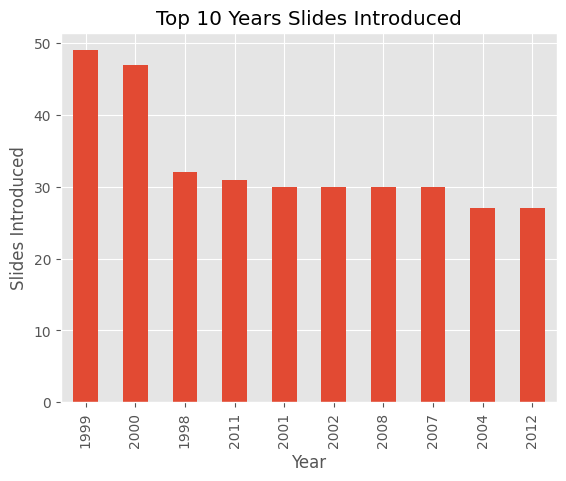

In [50]:
ax = df.yearintroduced\
.value_counts()\
.sort_values(ascending=False)\
.head(10)\
.plot(kind='bar',title='Top 10 Years Slides Introduced')


ax.set_xlabel('Year')
ax.set_ylabel('Slides Introduced')


Text(0, 0.5, 'frequency')

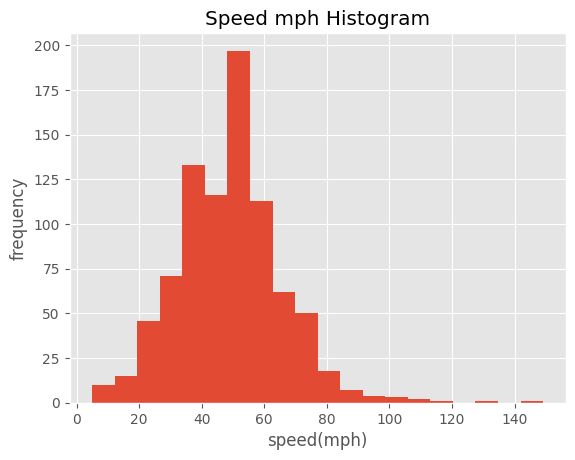

In [51]:
ax = df_dedup2.speedmph.plot(kind='hist',bins= 20,title='Speed mph Histogram')
ax.set_xlabel('speed(mph)')
ax.set_ylabel('frequency')

# Step 4 Feature Relationship
- Scatterplot
- Heatmap
- Pairplot
- Groupby Comparision

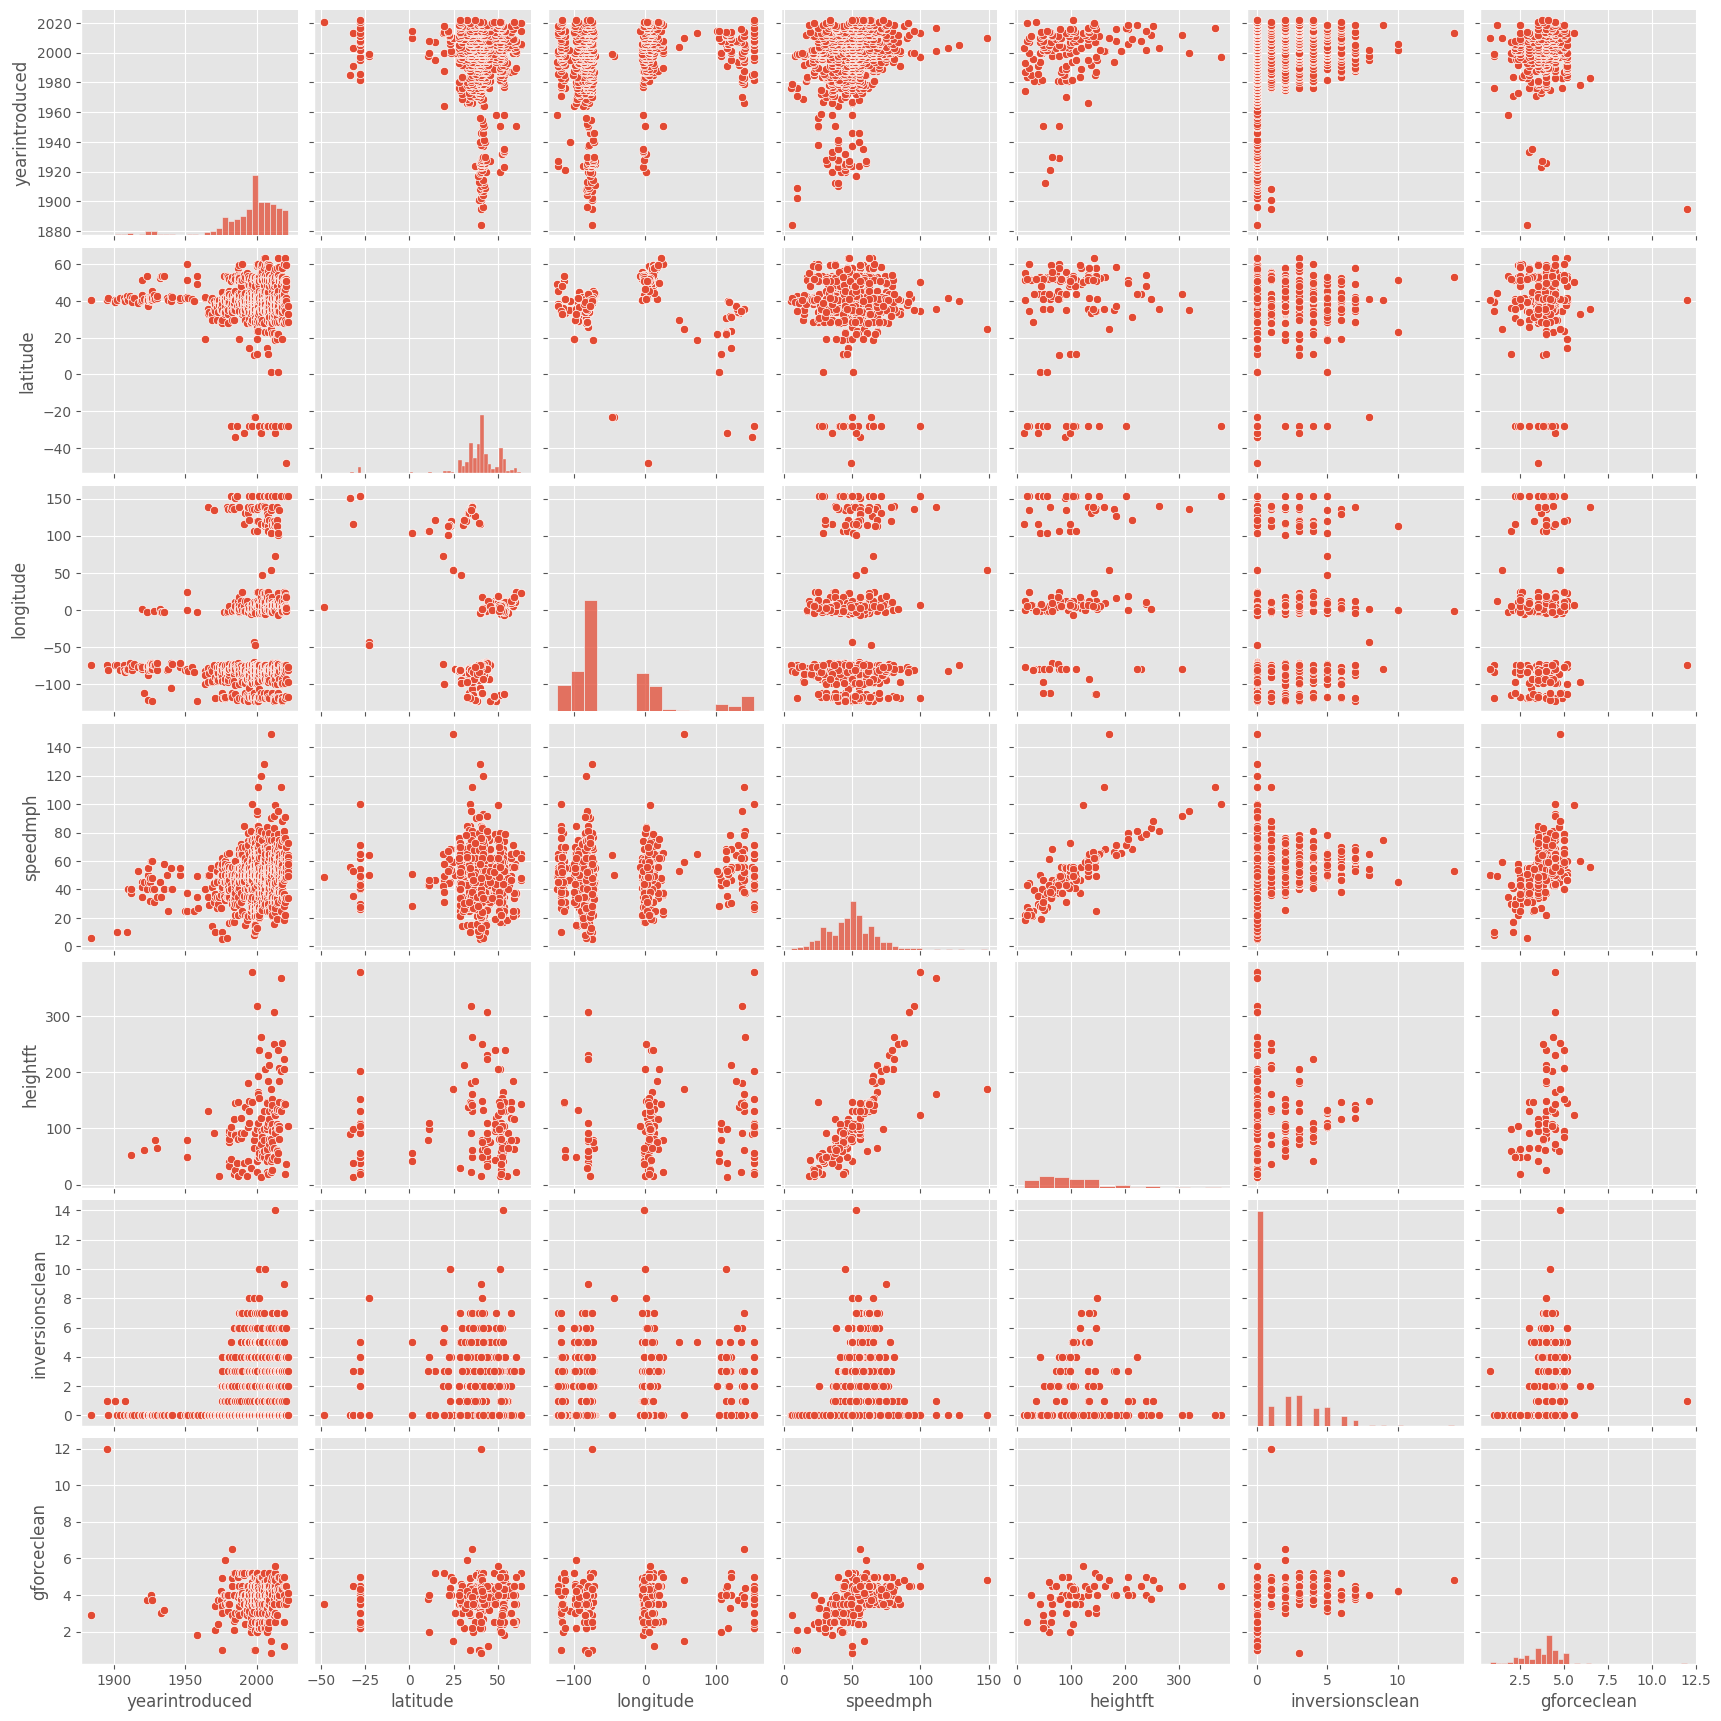

In [52]:
sns.pairplot(df_dedup2)

In [53]:
df.head()

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


In [58]:
df_dedup2.head()

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


<Axes: title={'center': 'Speed vs Height Correlation'}, xlabel='Speed', ylabel='Height'>

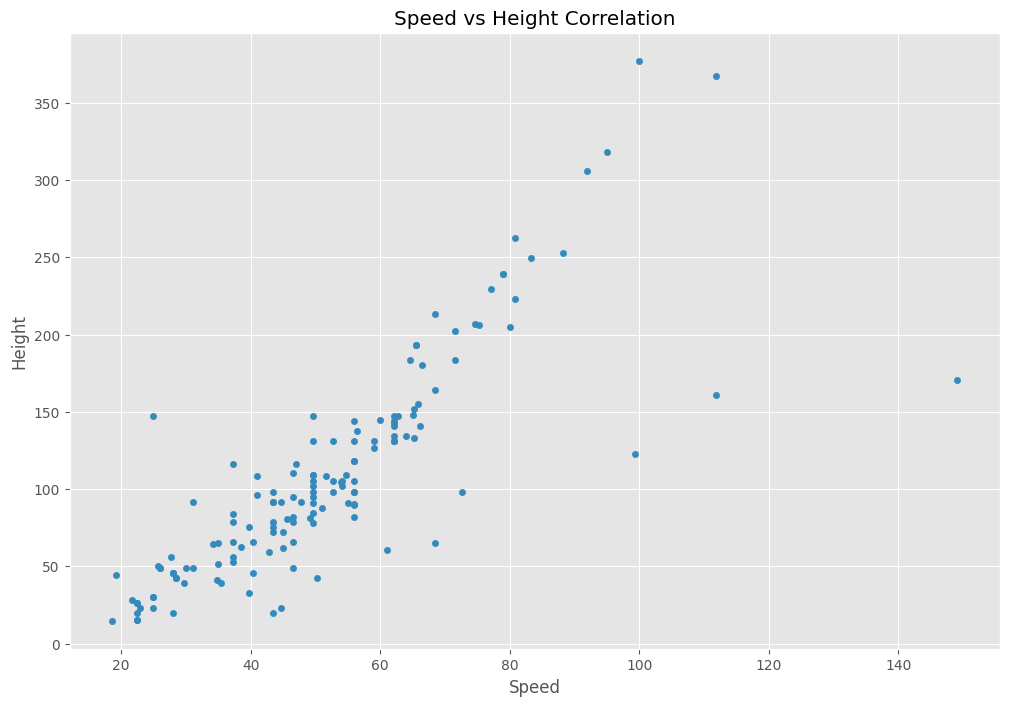

In [69]:
df_dedup2.plot(kind='scatter',
              x = 'speedmph',
              y = 'heightft',
              title = 'Speed vs Height Correlation',
               figsize=(12,8),
               xlabel='Speed',
               ylabel='Height')



In [80]:
df_dedup2.head()



,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


# Plots

### Scatter plot between speedmph and heightft (broken by typemain )
### Average height by year
### Average speed by year
### number of rides by location
### number of rides by typemain
### Growth in number of rides by time
## Average inversions per typemain
### Average gforce per typemain
### Status as of today by location
### number of locations

```
# This is formatted as code
```




In [107]:
print('Uniques Values of Columns ')
for col in df_dedup2.columns.values:
  print(f'{col} : {df_dedup2[col].nunique()}')

Uniques Values of Columns 
coastername : 990
location : 280
status : 15
manufacturer : 102
yearintroduced : 101
latitude : 688
longitude : 691
typemain : 3
openingdate : 602
speedmph : 176
heightft : 92
inversionsclean : 12
gforceclean : 45


# Scatter plot between speedmph and heightft (broken by typemain )

Text(5.069444444444445, 0.5, 'Height')

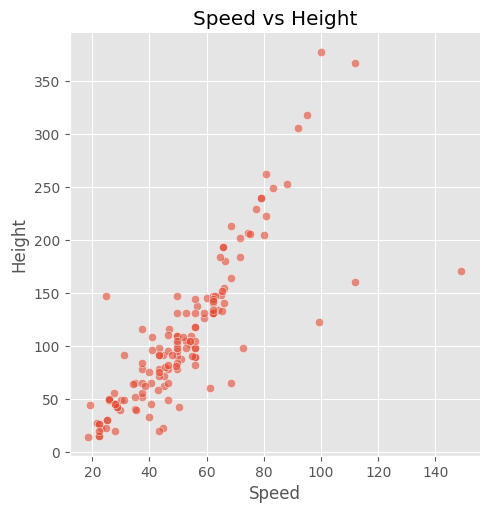

In [78]:
sns.relplot(df_dedup2, x='speedmph',y= 'heightft',kind='scatter', alpha = 0.6)
plt.title('Speed vs Height')
plt.xlabel('Speed')
plt.ylabel('Height')

In [110]:
df_dedup2.head()

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


Text(1012.4490740740741, 0.5, 'Height')

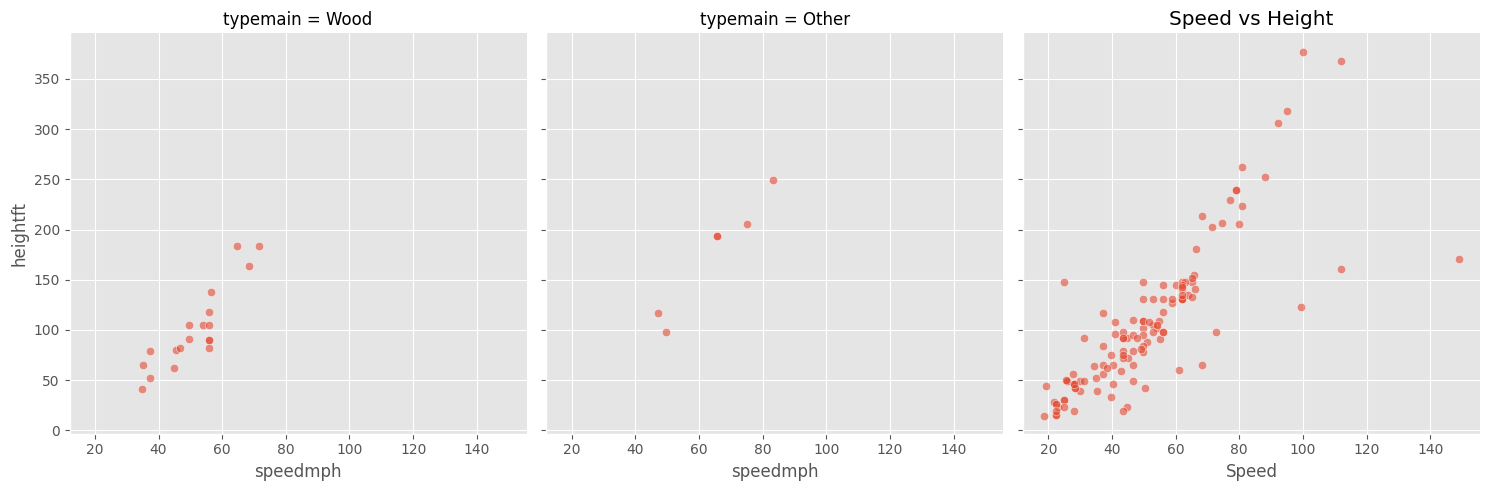

In [111]:
sns.relplot(df_dedup2, x='speedmph',y= 'heightft',kind='scatter', alpha = 0.6, col='typemain')
plt.title('Speed vs Height')
plt.xlabel('Speed')
plt.ylabel('Height')

# Average height by year

In [112]:
df_dedup2.columns

Index(['coastername', 'location', 'status', 'manufacturer', 'yearintroduced',
       'latitude', 'longitude', 'typemain', 'openingdate', 'speedmph',
       'heightft', 'inversionsclean', 'gforceclean'],
      dtype='object')

<Axes: xlabel='yearintroduced'>

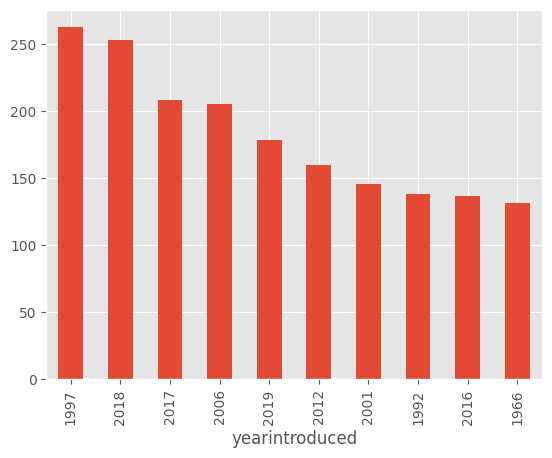

In [122]:
df_dedup2[~df_dedup2['heightft'].isnull()].groupby(['yearintroduced'])['heightft'].mean().sort_values(ascending=False).head(10).plot(kind='bar')


Inference - The heighest ride was introduced in 1997. The second heightest to that only came after 21 year later in 2018
More recently the manufacturers are not focusing on height

# Average speed by year

<Axes: xlabel='yearintroduced'>

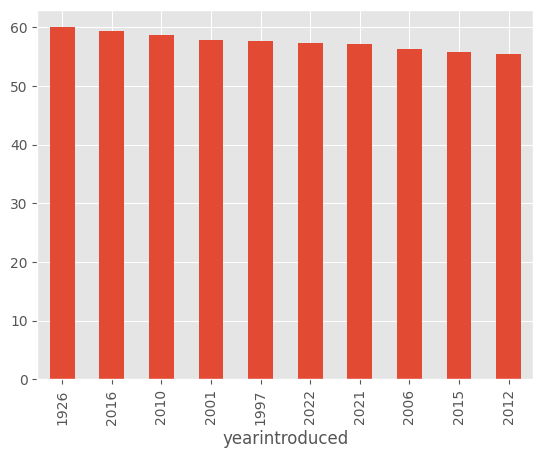

In [140]:
df_dedup2.groupby(['yearintroduced'])['speedmph'].mean().sort_values(ascending=False).head(10).plot(kind='bar')

Inference - The fastest rides were introduced back in 1926 and ever since the speed has not been the factor for thrill

# number of rides by location

'\ncounts = (\n    df_dedup2.groupby("location").size().reset_index(name="count")\n)\nresult = counts[counts["count"] > 10]\n\n\nnew_df = df_dedup2.groupby("location").size().reset_index(name="count")\nnew_df[new_df[\'count\'] > 10 ]\n'

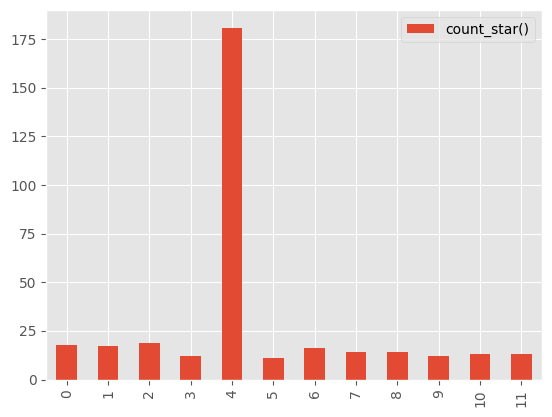

In [189]:
import duckdb as db
db.query('Select location, count(*) from df_dedup2 group by location having count(*) > 10 ').to_df().plot(kind='bar')


"""
counts = (
    df_dedup2.groupby("location").size().reset_index(name="count")
)
result = counts[counts["count"] > 10]


new_df = df_dedup2.groupby("location").size().reset_index(name="count")
new_df[new_df['count'] > 10 ]
"""

<Axes: xlabel='location'>

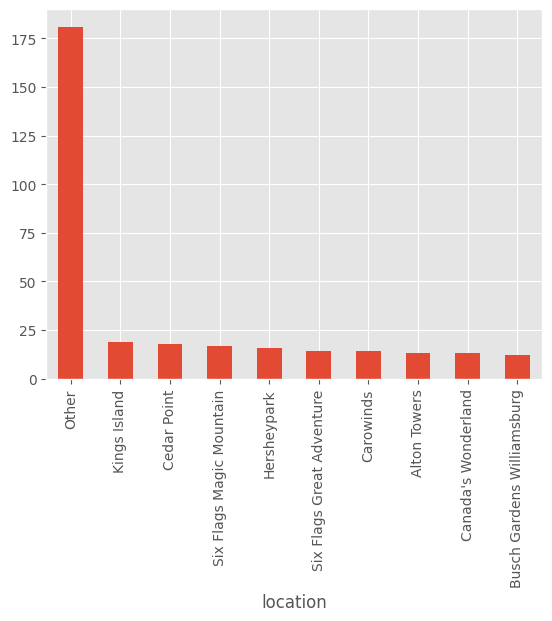

In [175]:
df_dedup2.groupby("location").size().sort_values(ascending=False).head(10).plot(kind='bar')

# number of rides by typemain

In [194]:
df_dedup2.groupby('typemain').size() / len(df_dedup2)


,0
typemain,
Other,0.071717
Steel,0.735354
Wood,0.192929


# Growth in number of rides by time

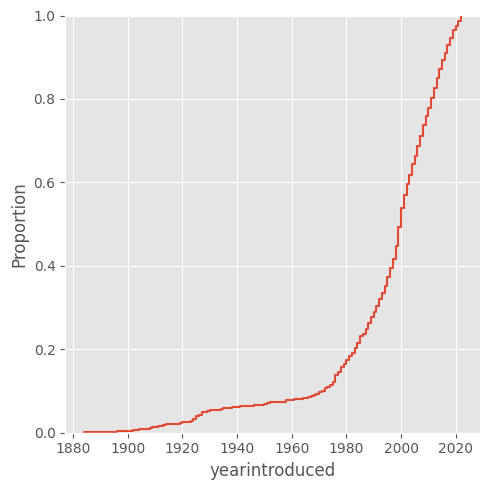

In [204]:
sns.displot(df_dedup2.groupby(['yearintroduced']).size().sort_index().reset_index(name='count'), x='yearintroduced', weights='count', kind='ecdf')

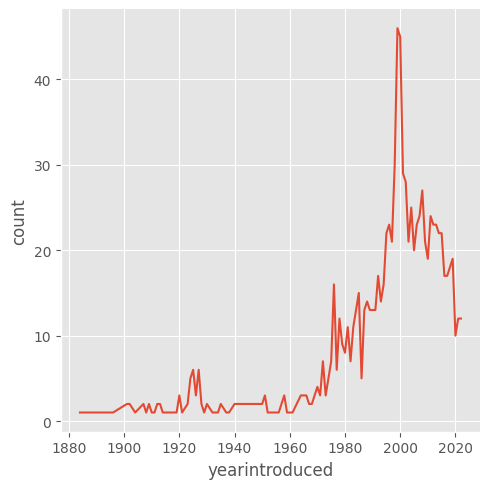

In [205]:
sns.relplot(df_dedup2.groupby(['yearintroduced']).size().sort_index().reset_index(name='count'), x='yearintroduced', y='count', kind='line')

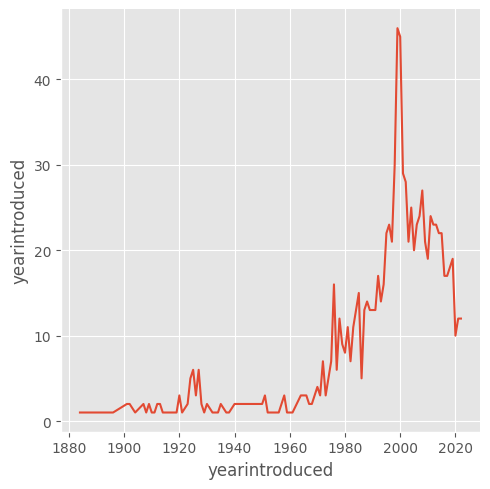

In [225]:
sns.relplot(df_dedup2,x='yearintroduced', y ='yearintroduced', estimator=len, kind = 'line')

# Average inversions per typemain

<Axes: xlabel='typemain'>

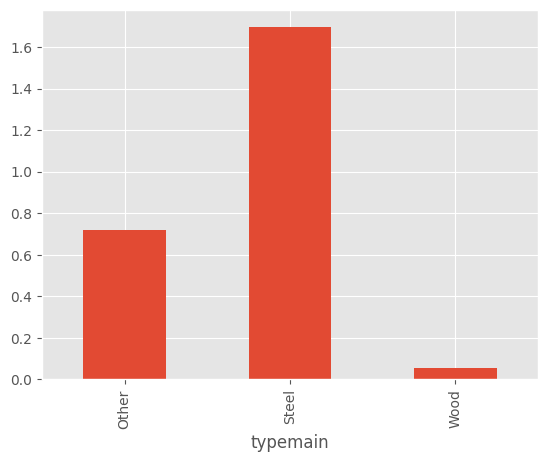

In [228]:
df_dedup2.groupby('typemain')['inversionsclean'].mean().plot(kind='bar')

# Average gforce per typemain

typemain
Other    3.877273
Steel    3.834037
Wood     3.680233
Name: gforceclean, dtype: float64


<Axes: xlabel='typemain'>

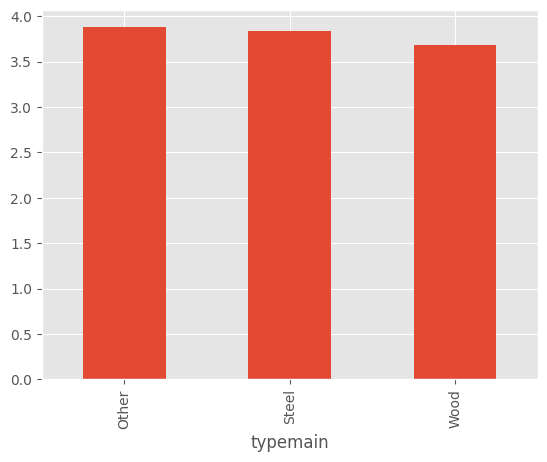

In [231]:
print(df_dedup2.groupby('typemain')['gforceclean'].mean())
df_dedup2.groupby('typemain')['gforceclean'].mean().plot(kind='bar')

# Status as of today by location

In [226]:
df_dedup2.head()

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN


In [238]:
df_dedup2['status'].unique()

array(['Removed', 'Closed', 'Operating', nan, 'Not Currently Operating',
       'In Production', 'Discontinued',
       'closed for maintenance as of july 30 no reopening date known',
       'Closed in 2021', 'SBNO December 2019', 'Under construction',
       'Temporarily Closed', 'SBNO (Standing But Not Operating)',
       'Temporarily closed',
       'Chapter 7 bankruptcy; rides dismantled and sold; property sold',
       'Under Maintenance'], dtype=object)

In [241]:
df_dedup2['status'].value_counts()

,count
status,
Operating,646
Removed,133
Closed,23
Under construction,14
In Production,11
Discontinued,7
Chapter 7 bankruptcy; rides dismantled and sold; property sold,2
closed for maintenance as of july 30 no reopening date known,1
Not Currently Operating,1


In [252]:
mapper = { val : val if val in ['Operating','Removed','Closed'] else 'NonFunctional' for val in df_dedup2['status'].unique()}
df_dedup2['status'] = df_dedup2['status'].map(mapper)

In [260]:


round((df_dedup2.groupby('status').size().sort_values(ascending=False) / len(df_dedup2)) * 100,2)

,0
status,
Operating,65.25
NonFunctional,18.99
Removed,13.43
Closed,2.32


# number of locations

In [268]:
df_dedup2.groupby(['location']).size().sort_values(ascending=False).head(10).reset_index(name='cnt')

,location,cnt
0,Other,181
1,Kings Island,19
2,Cedar Point,18
3,Six Flags Magic Mountain,17
4,Hersheypark,16
5,Six Flags Great Adventure,14
6,Carowinds,14
7,Alton Towers,13
8,Canada's Wonderland,13
9,Busch Gardens Williamsburg,12


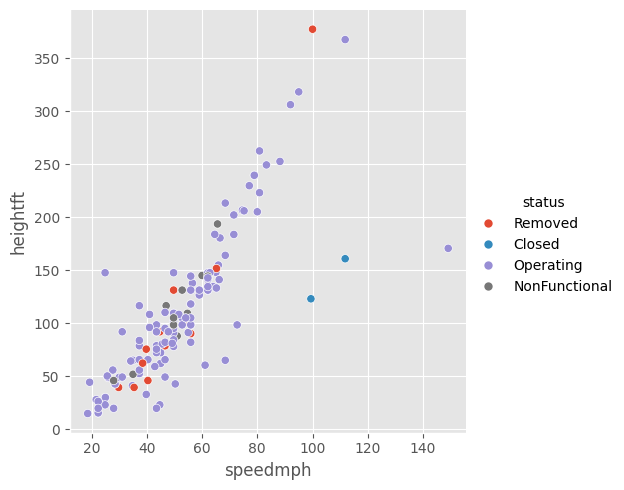

In [285]:
ax = sns.relplot(data=df_dedup2, x='speedmph',y='heightft',kind='scatter',hue='status')


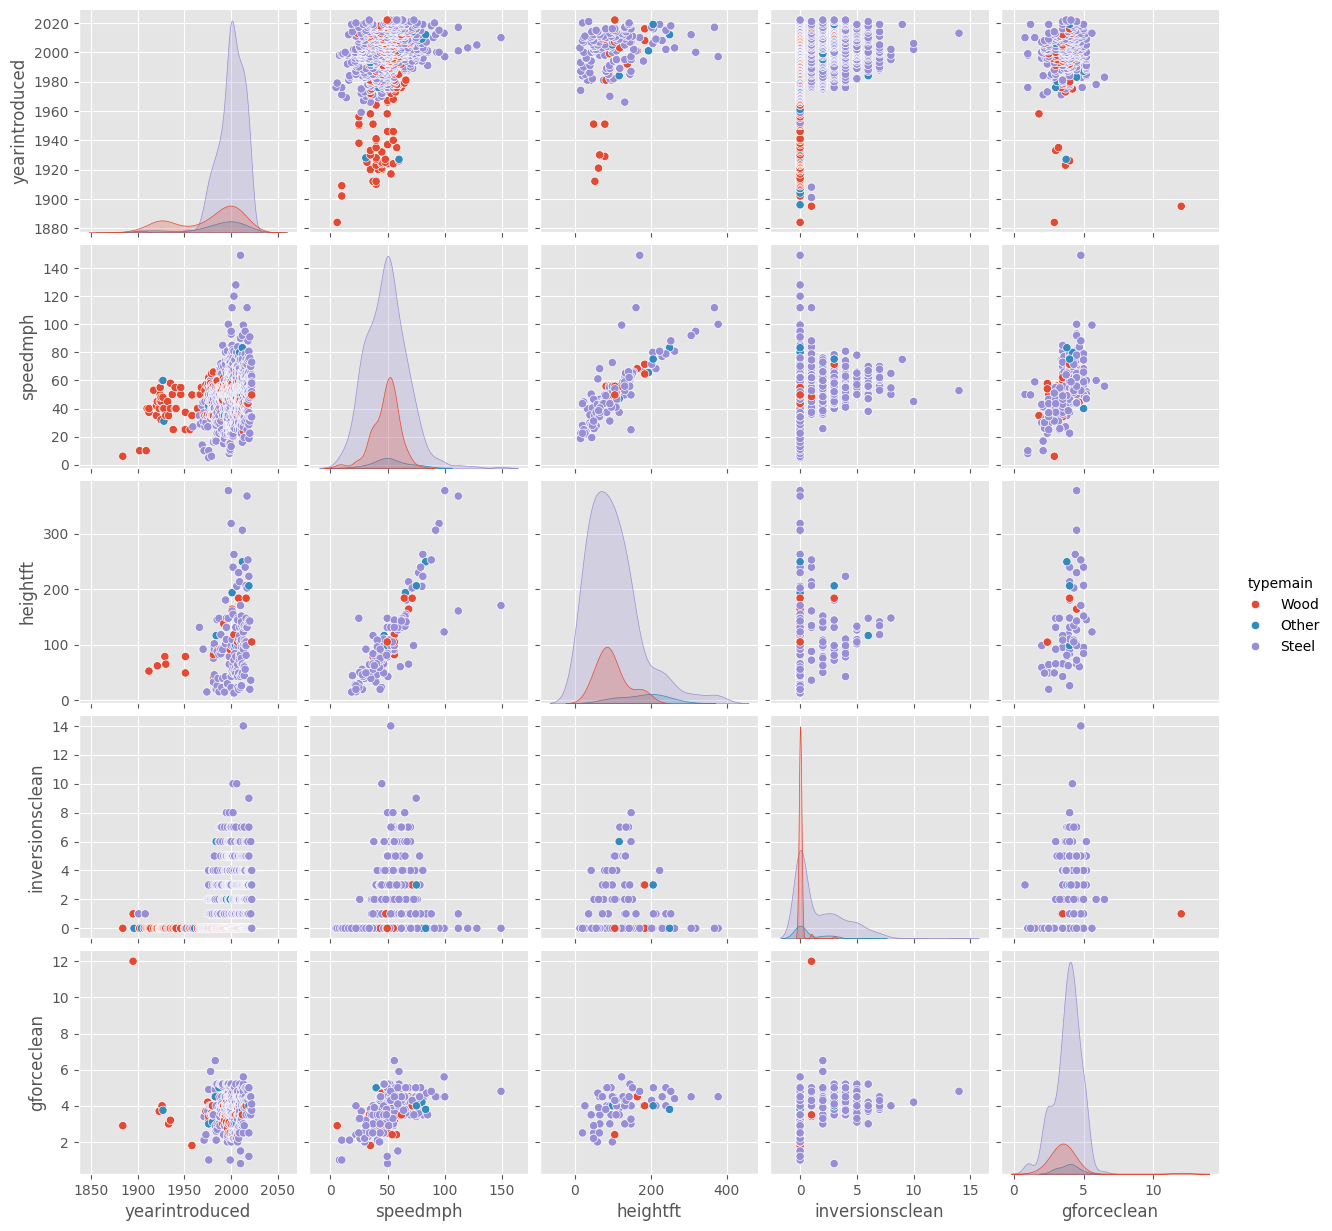

In [289]:
sns.pairplot(df_dedup2, vars= ['yearintroduced','speedmph','heightft','inversionsclean','gforceclean'], hue='typemain')

In [296]:
df_corr = df_dedup2[['yearintroduced','speedmph','heightft','inversionsclean','gforceclean'] ].dropna().corr()

<Axes: >

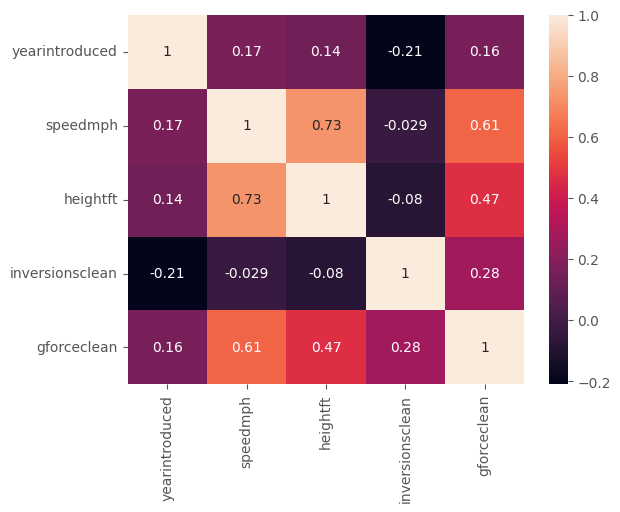

In [297]:
sns.heatmap(df_corr, annot=True)

In [302]:
df_dedup2.groupby('location')['speedmph'].mean().sort_values(ascending=False)

,speedmph
location,
Ferrari World Abu Dhabi,111.85
Ferrari Land,111.80
Nürburgring,99.40
Primm Valley Resorts,80.00
China Dinosaurs Park,78.30
...,...
Tolchester Beach Park,NaN
"Universal Orlando Resort, Orlando, Florida, United States",NaN
Walygator Parc,NaN


In [311]:
df_dedup2.groupby(['coastername','location'])['speedmph'].max().sort_values(ascending=False)

,,speedmph
coastername,location,
Formula Rossa,Ferrari World Abu Dhabi,149.1
Kingda Ka,Six Flags Great Adventure,128.0
Top Thrill Dragster,Cedar Point,120.0
Red Force (roller coaster),Ferrari Land,111.8
Do-Dodonpa,Fuji-Q Highland,111.8
...,...,...
Wonder Mountain's Guardian,Canada's Wonderland,NaN
Woodstock's Express (California's Great America),Other,NaN
Zach's Zoomer,Michigan's Adventure,NaN


In [303]:
df_dedup2

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
0,Switchback Railway,Coney Island,Removed,LaMarcus Adna Thompson,1884,40.5740,-73.9780,Wood,1884-06-16,6.0,NaN,0,2.9
1,Flip Flap Railway,Sea Lion Park,Removed,Lina Beecher,1895,40.5780,-73.9790,Wood,1895-01-01,NaN,NaN,1,12.0
2,Switchback Railway (Euclid Beach Park),"Cleveland, Ohio, United States",Closed,NaN,1896,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
3,Loop the Loop (Coney Island),Other,Removed,Edwin Prescott,1901,40.5745,-73.9780,Steel,1901-01-01,NaN,NaN,1,NaN
4,Loop the Loop (Young's Pier),Other,Removed,Edwin Prescott,1901,39.3538,-74.4342,Steel,1901-01-01,NaN,NaN,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
985,Ice Breaker (roller coaster),SeaWorld Orlando,NonFunctional,Premier Rides,2022,28.4088,-81.4633,Steel,2022-02-01,52.0,NaN,0,NaN
986,Leviathan (Sea World),Sea World,NonFunctional,Martin & Vleminckx,2022,-27.9574,153.4263,Wood,2022-01-01,49.7,105.0,0,NaN
987,Pantheon (roller coaster),Busch Gardens Williamsburg,NonFunctional,Intamin,2022,37.2339,-76.6426,Steel,2022-01-01,73.0,NaN,2,NaN
988,Tumbili,Kings Dominion,NonFunctional,S&S – Sansei Technologies,2022,NaN,NaN,Steel,NaT,34.0,NaN,0,NaN


In [326]:
df_map = df_dedup2.groupby('location').size().reset_index(name='cnt')

In [327]:
df_map

,location,cnt
0,"2904 Fantasy Way Myrtle Beach, South Carolina,...",2
1,"63rd and N.W. Expressway, Oklahoma City, Oklah...",1
2,"8039 Beach BoulevardBuena Park, California 906...",1
3,Adlabs Imagica,1
4,Adventure City,1
...,...,...
275,Xishuangbanna Theme Park,1
276,Yomiuriland,4
277,ZDT's Amusement Park,1
278,Zoosafari Fasanolandia,1


In [325]:
df_dedup2.iloc[df_map[df_map['cnt'] > 10 ].index]

,coastername,location,status,manufacturer,yearintroduced,latitude,longitude,typemain,openingdate,speedmph,heightft,inversionsclean,gforceclean
11,Aero Dips,"Cleveland, Ohio, United States",Closed,NaN,1909,41.5800,-81.5700,Other,NaT,NaN,NaN,0,NaN
21,Jack Rabbit (Clementon Park),Clementon Park,Removed,Philadelphia Toboggan Coasters,1919,39.8041,-74.9844,Wood,1919-01-01,NaN,NaN,0,NaN
29,Giant Dipper,Santa Cruz Beach Boardwalk,Operating,Arthur Looff,1924,36.9647,-122.0153,Wood,1924-05-17,55.0,NaN,0,NaN
33,Big Dipper (Geauga Lake),Geauga Lake,Removed,NaN,1925,41.3491,-81.3780,Wood,1925-01-01,32.0,NaN,0,NaN
35,Giant Dipper (Belmont Park),Other,Operating,"Frank Prior, Fredrick Church",1925,NaN,NaN,Wood,1925-07-04,48.0,NaN,0,NaN
38,Thunderbolt (Savin Rock),Savin Rock,Removed,Traver Engineering,1925,41.2570,-72.9500,Wood,1925-05-05,NaN,NaN,0,NaN
115,Glissade (roller coaster),Busch Gardens Williamsburg,Removed,Anton Schwarzkopf,1975,37.2350,-76.6440,Steel,1975-01-01,NaN,NaN,0,NaN
131,Python (Busch Gardens Tampa Bay),Busch Gardens Tampa Bay,Removed,Arrow Development,1976,28.0390,-82.4251,Steel,1976-07-01,40.0,NaN,2,NaN
132,The New Revolution (roller coaster),Six Flags Magic Mountain,Operating,Anton Schwarzkopf,1976,34.4228,-118.5964,Steel,1976-05-08,55.0,NaN,1,4.9
185,Sea Viper (roller coaster),Sea World,Removed,Arrow Dynamics,1982,-27.9569,153.4265,Steel,1982-09-17,43.5,91.9,3,NaN


# Find the location with mininum of 10 rides and with fastest rides

<Axes: title={'center': 'Average speed by location (with min of 10 rides)'}, xlabel='location'>

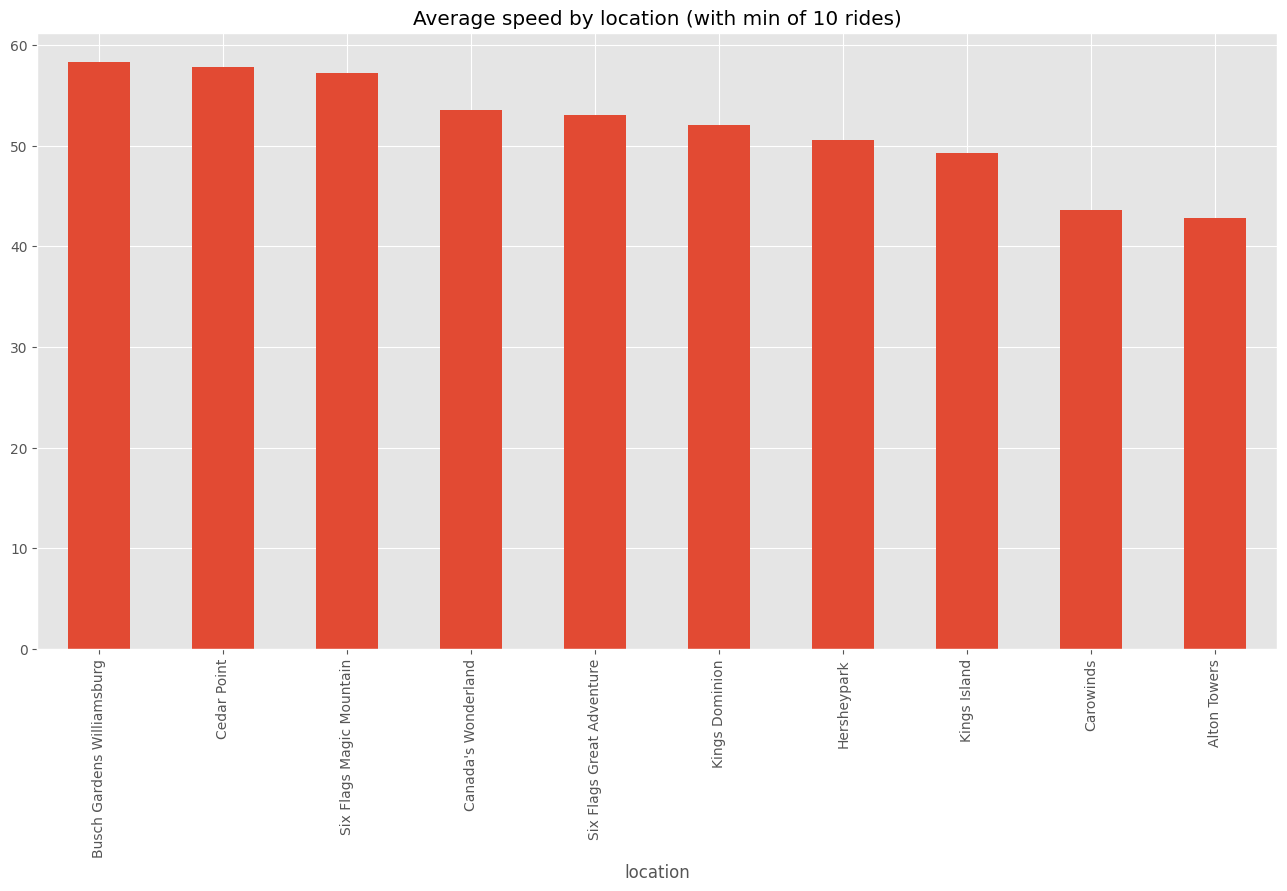

In [338]:
df_dedup2.query("location != 'Other'")\
.groupby('location')['speedmph']\
.agg(['mean','count'])\
.query('count >=10') \
.sort_values('mean',ascending=False)['mean']\
.plot(kind='bar',figsize=(16,8),title='Average speed by location (with min of 10 rides)')

Text(0, 0.5, 'Average Coaster Speed per location')

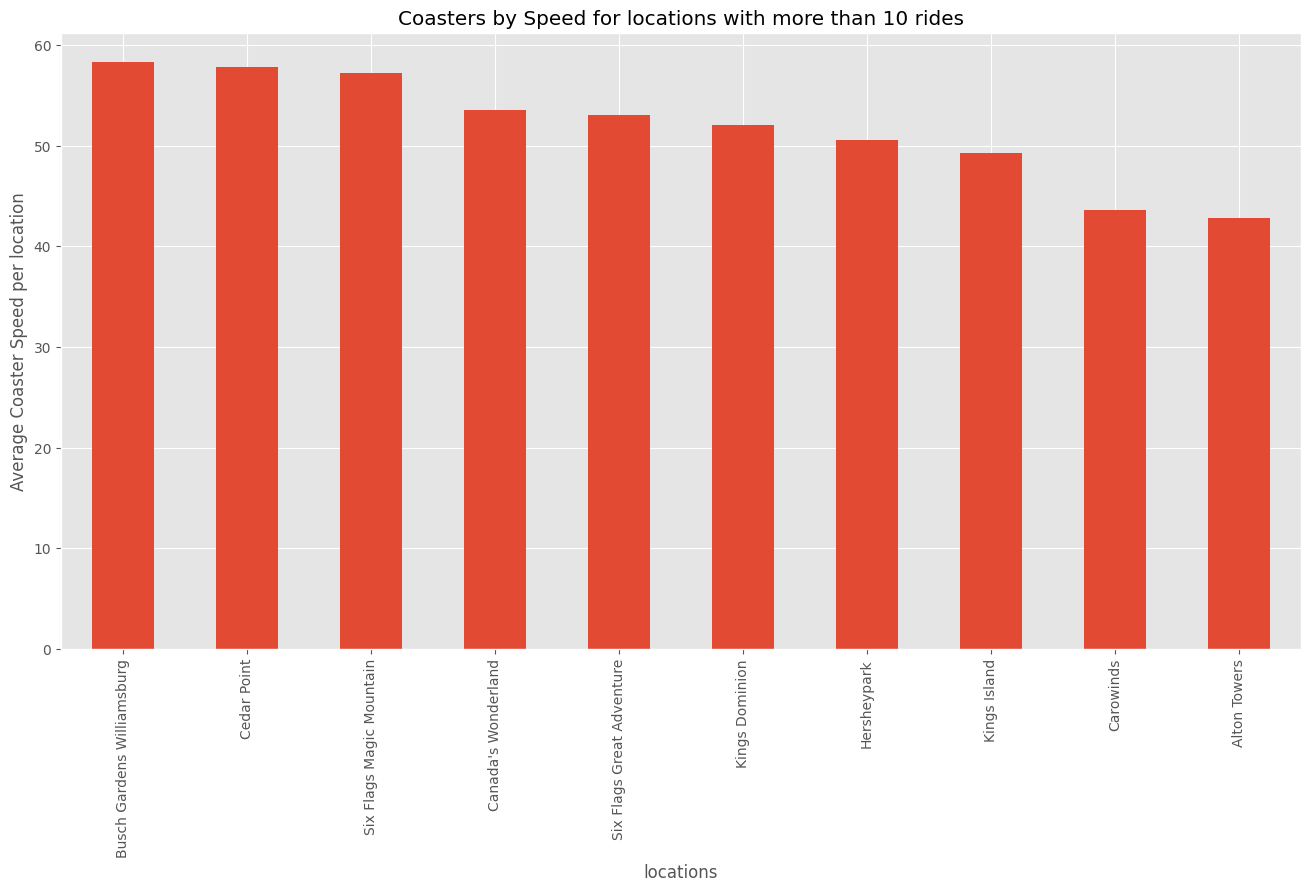

In [360]:
ax = df_dedup2.query("location!='Other'")\
.groupby('location')['speedmph']\
.agg(['mean','count'])\
.query("count>=10")\
.sort_values(['mean'], ascending=False)['mean']\
.plot(kind='bar',figsize=(16,8),title='Coasters by Speed for locations with more than 10 rides')
ax.set_xlabel('locations')
ax.set_ylabel('Average Coaster Speed per location')